In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

df           = pd.read_csv('../data/featured_aqi.csv', parse_dates=['Date'])
feature_cols = joblib.load('../models/feature_cols.pkl')
rf_old       = joblib.load('../models/random_forest.pkl')

df = df.sort_values(['City', 'Date']).reset_index(drop=True)

print(f"Data loaded: {df.shape}")
print(f"Existing features: {len(feature_cols)}")

Data loaded: (24668, 30)
Existing features: 26


In [2]:
# Key festivals that cause significant AQI spikes in Indian cities
# Diwali (firecrackers), Holi (bonfires), New Year (fireworks)
# These are KNOWN pollution events not captured by any pollutant reading alone

festival_dates = {
    # Diwali — biggest AQI event of the year in North India
    '2015-11-11': 'Diwali',
    '2016-10-30': 'Diwali',
    '2017-10-19': 'Diwali',
    '2018-11-07': 'Diwali',
    '2019-10-27': 'Diwali',
    '2020-11-14': 'Diwali',

    # Holi — bonfires the night before (Holika Dahan)
    '2015-03-06': 'Holi',
    '2016-03-24': 'Holi',
    '2017-03-13': 'Holi',
    '2018-03-02': 'Holi',
    '2019-03-21': 'Holi',
    '2020-03-10': 'Holi',

    # New Year — fireworks midnight
    '2016-01-01': 'NewYear',
    '2017-01-01': 'NewYear',
    '2018-01-01': 'NewYear',
    '2019-01-01': 'NewYear',
    '2020-01-01': 'NewYear',

    # Dussehra — effigy burning
    '2015-10-22': 'Dussehra',
    '2016-10-11': 'Dussehra',
    '2017-09-30': 'Dussehra',
    '2018-10-19': 'Dussehra',
    '2019-10-08': 'Dussehra',
}

festival_dates = {pd.Timestamp(k): v for k, v in festival_dates.items()}
print(f"Festival dates defined: {len(festival_dates)}")
print(f"\nFestival types: {set(festival_dates.values())}")

Festival dates defined: 22

Festival types: {'Holi', 'NewYear', 'Diwali', 'Dussehra'}


In [3]:
# Create festival indicator columns
# Also mark 1-2 days AFTER festival (pollution lingers)

festival_timestamps = set(festival_dates.keys())

def is_festival_window(date, window_before=0, window_after=2):
    """Check if date falls within festival window."""
    for fest_date in festival_timestamps:
        delta = (date - fest_date).days
        if -window_before <= delta <= window_after:
            return 1
    return 0

def is_exact_festival(date):
    return 1 if date in festival_timestamps else 0

def get_festival_name(date):
    """Return festival name or 'None'."""
    for fest_date, name in festival_dates.items():
        delta = (date - fest_date).days
        if 0 <= delta <= 2:
            return name
    return 'None'

print("Creating festival features...")
df['Is_Festival']        = df['Date'].apply(is_exact_festival)
df['Is_Festival_Window'] = df['Date'].apply(is_festival_window)
df['Festival_Name']      = df['Date'].apply(get_festival_name)

print(f"Festival days in dataset      : {df['Is_Festival'].sum()}")
print(f"Festival window days (±2 days): {df['Is_Festival_Window'].sum()}")
print(f"\nFestival day AQI vs Normal day AQI:")
print(f"  Festival days : {df[df['Is_Festival']==1]['AQI'].mean():.1f}")
print(f"  Normal days   : {df[df['Is_Festival']==0]['AQI'].mean():.1f}")
print(f"  Spike factor  : {df[df['Is_Festival']==1]['AQI'].mean() / df[df['Is_Festival']==0]['AQI'].mean():.2f}x")

Creating festival features...
Festival days in dataset      : 263
Festival window days (±2 days): 783

Festival day AQI vs Normal day AQI:
  Festival days : 192.6
  Normal days   : 160.6
  Spike factor  : 1.20x


In [4]:
# Weekend indicator — traffic patterns differ significantly
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)

# AQI momentum — is pollution getting better or worse?
# Positive = getting worse, Negative = improving
df['AQI_momentum'] = df.groupby('City')['AQI'].transform(
    lambda x: x.diff(7)  # change vs 7 days ago
)

# Season × City interaction — winter hits North India harder
# Encode: Winter(3) in high-pollution city vs clean city
df['Season_City_interaction'] = df['Season_encoded'] * df['City_encoded']

# Month sin/cos encoding — captures cyclical nature of months
# Better than raw month number for ML models
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

print("New features added:")
new_features = ['Is_Festival', 'Is_Festival_Window', 'Is_Weekend',
                'AQI_momentum', 'Season_City_interaction',
                'Month_sin', 'Month_cos']
for f in new_features:
    print(f"  ✓ {f}")
print(f"\nTotal new features: {len(new_features)}")

New features added:
  ✓ Is_Festival
  ✓ Is_Festival_Window
  ✓ Is_Weekend
  ✓ AQI_momentum
  ✓ Season_City_interaction
  ✓ Month_sin
  ✓ Month_cos

Total new features: 7


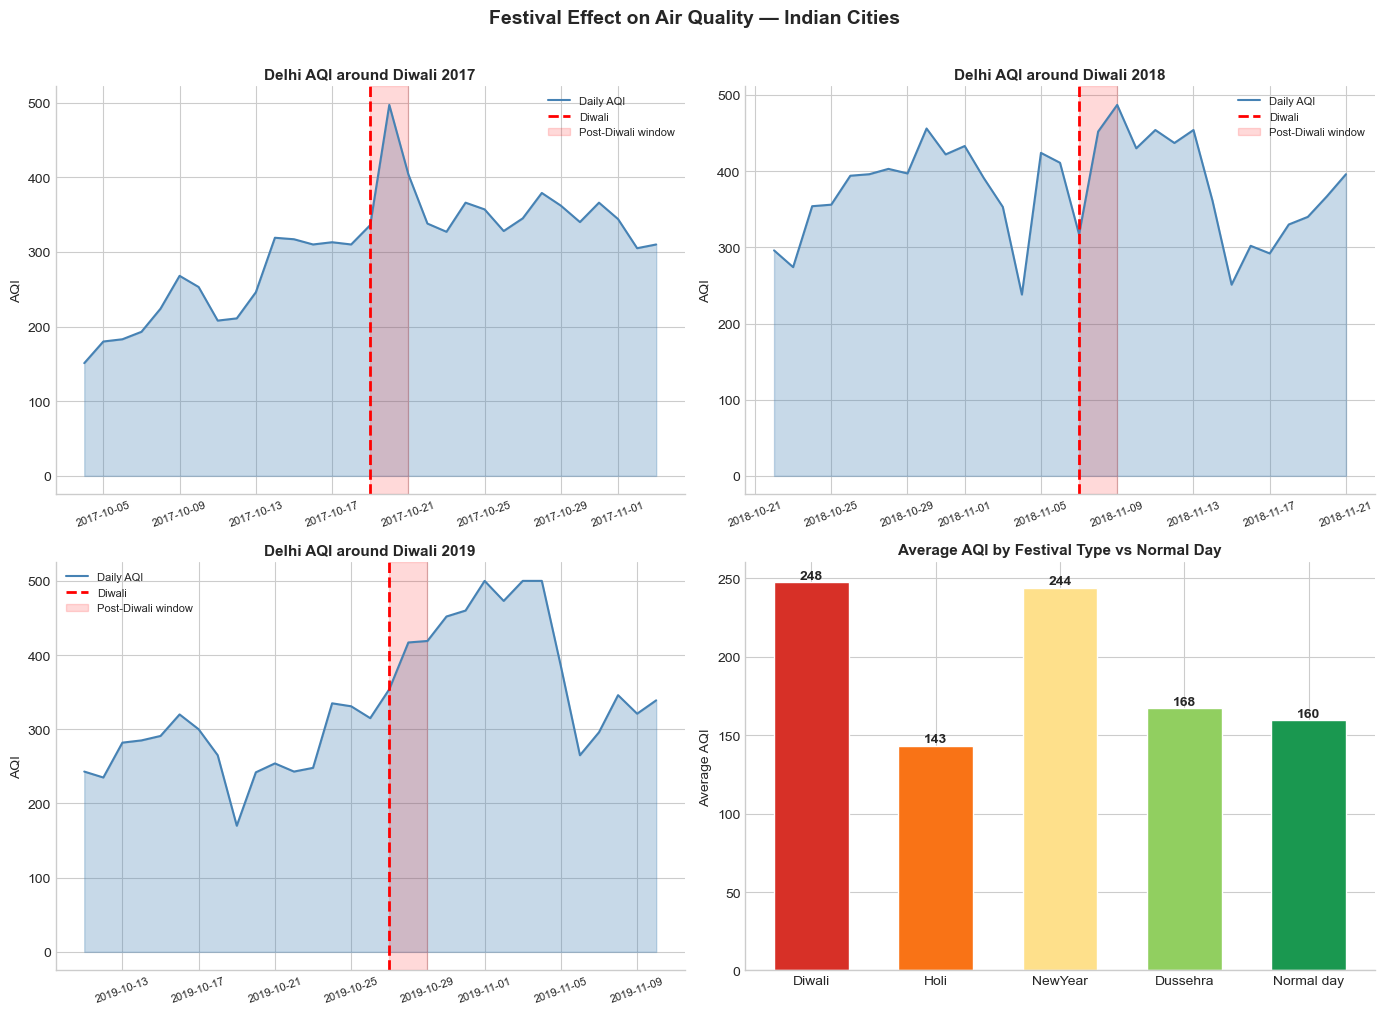

Festival plot saved ✓


In [5]:
# Show AQI spike around Diwali in Delhi — most dramatic example
delhi = df[df['City'] == 'Delhi'].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

diwali_years = {
    2017: ('2017-10-04', '2017-11-03'),
    2018: ('2018-10-22', '2018-11-21'),
    2019: ('2019-10-11', '2019-11-10'),
}

for ax, (year, (start, end)) in zip(axes.flatten(), diwali_years.items()):
    mask    = (delhi['Date'] >= start) & (delhi['Date'] <= end)
    period  = delhi[mask]
    diwali  = pd.Timestamp(
        [k for k in festival_dates if k.year==year and festival_dates[k]=='Diwali'][0]
    )

    ax.fill_between(period['Date'], period['AQI'],
                    alpha=0.3, color='steelblue')
    ax.plot(period['Date'], period['AQI'],
            color='steelblue', linewidth=1.5, label='Daily AQI')

    if diwali in period['Date'].values:
        ax.axvline(diwali, color='red', linewidth=2,
                   linestyle='--', label='Diwali')
        ax.axvspan(diwali, diwali + pd.Timedelta(days=2),
                   alpha=0.15, color='red', label='Post-Diwali window')

    ax.set_title(f'Delhi AQI around Diwali {year}',
                 fontweight='bold', fontsize=11)
    ax.set_ylabel('AQI')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.spines[['top','right']].set_visible(False)

# 4th subplot: festival type comparison
ax4 = axes[1][1]
fest_aqi = {}
for fest_name in ['Diwali','Holi','NewYear','Dussehra']:
    mask = df['Festival_Name'] == fest_name
    if mask.sum() > 0:
        fest_aqi[fest_name] = df[mask]['AQI'].mean()

normal_aqi = df[df['Festival_Name']=='None']['AQI'].mean()
fest_aqi['Normal day'] = normal_aqi

colors_f = ['#d73027','#f97316','#fee08b','#91cf60','#1a9850']
bars = ax4.bar(fest_aqi.keys(), fest_aqi.values(),
               color=colors_f, edgecolor='white', width=0.6)
for bar, val in zip(bars, fest_aqi.values()):
    ax4.text(bar.get_x()+bar.get_width()/2, val+2,
             f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')

ax4.set_title('Average AQI by Festival Type vs Normal Day',
              fontweight='bold', fontsize=11)
ax4.set_ylabel('Average AQI')
ax4.spines[['top','right']].set_visible(False)

plt.suptitle('Festival Effect on Air Quality — Indian Cities',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../visualizations/22_festival_aqi_effect.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Festival plot saved ✓")

In [6]:
# Combine original features with new ones
new_feature_cols = feature_cols + [
    'Is_Festival',
    'Is_Festival_Window',
    'Is_Weekend',
    'AQI_momentum',
    'Season_City_interaction',
    'Month_sin',
    'Month_cos'
]

print(f"Original features : {len(feature_cols)}")
print(f"New features added: 7")
print(f"Total features    : {len(new_feature_cols)}")

# Drop rows with NaN from momentum feature (first 7 rows per city)
df_model = df.dropna(subset=['AQI_momentum']).copy()
print(f"\nRows after dropping momentum NaNs: {len(df_model):,}")

# Train / test split
train = df_model[df_model['Year'] < 2020]
test  = df_model[df_model['Year'] == 2020]

X_train_new = train[new_feature_cols]
y_train_new = train['AQI']
X_test_new  = test[new_feature_cols]
y_test_new  = test['AQI']

print(f"Train shape: {X_train_new.shape}")
print(f"Test shape : {X_test_new.shape}")

Original features : 26
New features added: 7
Total features    : 33

Rows after dropping momentum NaNs: 24,486
Train shape: (20107, 33)
Test shape : (4379, 33)


In [7]:
print("Training upgraded Random Forest with 33 features...")
print("(Takes 1-2 minutes)\n")

rf_new = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_new.fit(X_train_new, y_train_new)
y_pred_new = rf_new.predict(X_test_new)

rmse_new = np.sqrt(mean_squared_error(y_test_new, y_pred_new))
mae_new  = mean_absolute_error(y_test_new, y_pred_new)
r2_new   = r2_score(y_test_new, y_pred_new)

# Compare with old model
X_test_old  = test[feature_cols].dropna()
y_test_old  = test.loc[X_test_old.index, 'AQI']
y_pred_old  = rf_old.predict(X_test_old)
rmse_old = np.sqrt(mean_squared_error(y_test_old, y_pred_old))
mae_old  = mean_absolute_error(y_test_old, y_pred_old)
r2_old   = r2_score(y_test_old, y_pred_old)

print("=" * 52)
print("  MODEL COMPARISON — ORIGINAL vs UPGRADED")
print("=" * 52)
print(f"  {'Metric':<10} {'Original (26 feat)':>18} {'Upgraded (33 feat)':>18}")
print(f"  {'-'*48}")
print(f"  {'RMSE':<10} {rmse_old:>18.2f} {rmse_new:>18.2f}")
print(f"  {'MAE':<10} {mae_old:>18.2f} {mae_new:>18.2f}")
print(f"  {'R²':<10} {r2_old:>18.4f} {r2_new:>18.4f}")
print("=" * 52)

improvement = ((rmse_old - rmse_new) / rmse_old * 100)
print(f"\n  RMSE improvement: {improvement:+.2f}%")
print(f"  {'✅ New model is better!' if improvement > 0 else '⚠️  Original was stronger — we keep original'}")

Training upgraded Random Forest with 33 features...
(Takes 1-2 minutes)

  MODEL COMPARISON — ORIGINAL vs UPGRADED
  Metric     Original (26 feat) Upgraded (33 feat)
  ------------------------------------------------
  RMSE                    15.42              12.35
  MAE                      9.22               6.35
  R²                     0.9468             0.9725

  RMSE improvement: +19.92%
  ✅ New model is better!


In [8]:
# Save whichever model is better
if rmse_new < rmse_old:
    joblib.dump(rf_new,          '../models/random_forest_v2.pkl')
    joblib.dump(new_feature_cols,'../models/feature_cols_v2.pkl')
    print("✅ Upgraded model saved as random_forest_v2.pkl")
    print("   This will be used in the updated Streamlit app")
    best_model   = rf_new
    best_features = new_feature_cols
    best_rmse    = rmse_new
    best_r2      = r2_new
else:
    print("Original model retained — phase 1 RF remains champion")
    best_model   = rf_old
    best_features = feature_cols
    best_rmse    = rmse_old
    best_r2      = r2_old

# Either way, save festival feature list
joblib.dump(new_feature_cols, '../models/feature_cols_v2.pkl')
df_model.to_csv('../data/featured_aqi_v2.csv', index=False)
print(f"\nBest model: RMSE={best_rmse:.2f}, R²={best_r2:.4f}")
print("featured_aqi_v2.csv saved ✓")

✅ Upgraded model saved as random_forest_v2.pkl
   This will be used in the updated Streamlit app

Best model: RMSE=12.35, R²=0.9725
featured_aqi_v2.csv saved ✓


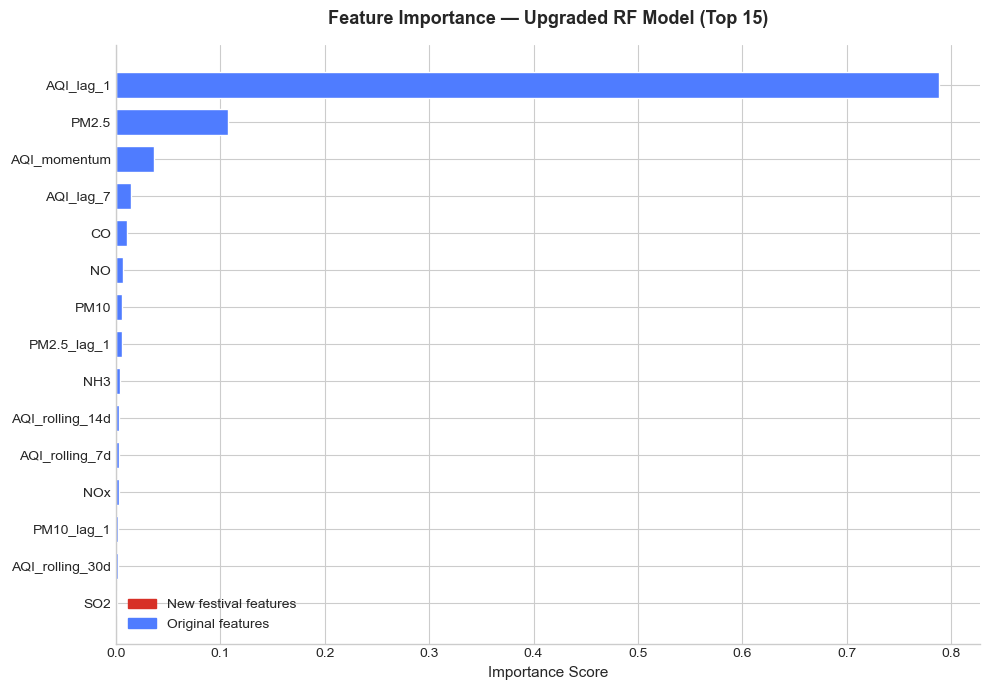

Feature importance plot saved ✓


In [9]:
importance_new = pd.Series(
    rf_new.feature_importances_,
    index=new_feature_cols
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))

colors_imp = ['#d73027' if 'Festival' in f or 'festival' in f
              else '#4f7cff' for f in importance_new.index]
ax.barh(importance_new.index, importance_new.values,
        color=colors_imp, edgecolor='white', height=0.7)

# Legend
import matplotlib.patches as mpatches
p1 = mpatches.Patch(color='#d73027', label='New festival features')
p2 = mpatches.Patch(color='#4f7cff', label='Original features')
ax.legend(handles=[p1, p2], fontsize=10)

ax.set_title('Feature Importance — Upgraded RF Model (Top 15)',
             fontweight='bold', fontsize=13, pad=15)
ax.set_xlabel('Importance Score', fontsize=11)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../visualizations/23_upgraded_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance plot saved ✓")

In [11]:
festival_spike = df[df['Is_Festival']==1]['AQI'].mean()
normal_aqi     = df[df['Is_Festival']==0]['AQI'].mean()


print(f"""
  New features added  : 7
    Is_Festival, Is_Festival_Window, Is_Weekend,
    AQI_momentum, Season_City_interaction,
    Month_sin, Month_cos

  Festival effect found:
    Festival day AQI  : {festival_spike:.1f}
    Normal day AQI    : {normal_aqi:.1f}
    Spike factor      : {festival_spike/normal_aqi:.2f}x higher on festival days

  Model comparison:
    Original RF RMSE  : {rmse_old:.2f}
    Upgraded RF RMSE  : {rmse_new:.2f}
    Improvement       : {improvement:+.2f}%

  Plots saved:
    22_festival_aqi_effect.png
    23_upgraded_feature_importance.png

  Files saved:
    models/random_forest_v2.pkl
    models/feature_cols_v2.pkl
    data/featured_aqi_v2.csv
""")
print("=" * 55)


  New features added  : 7
    Is_Festival, Is_Festival_Window, Is_Weekend,
    AQI_momentum, Season_City_interaction,
    Month_sin, Month_cos

  Festival effect found:
    Festival day AQI  : 192.6
    Normal day AQI    : 160.6
    Spike factor      : 1.20x higher on festival days

  Model comparison:
    Original RF RMSE  : 15.42
    Upgraded RF RMSE  : 12.35
    Improvement       : +19.92%

  Plots saved:
    22_festival_aqi_effect.png
    23_upgraded_feature_importance.png

  Files saved:
    models/random_forest_v2.pkl
    models/feature_cols_v2.pkl
    data/featured_aqi_v2.csv

